In [1]:
import pandas as pd
import numpy as np
import os

PLOTS_DIR = 'presentation_plots'
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f'Plots will be saved to: {PLOTS_DIR}/')

Plots will be saved to: presentation_plots/


In [41]:
daily_df = pd.read_csv('daily_df.csv')
daily_df = daily_df.set_index('Timestamp')
daily_df.index = pd.to_datetime(daily_df.index)
daily_df.head()

,temp_mean,temp_min,temp_max,dewpt_mean,humidity_mean,wind_sin,wind_cos,wind_speed_mean,wind_speed_max,mslp_mean,...,wind_cos_lag3,temp_mean_lag7,temp_max_lag7,humidity_mean_lag7,mslp_mean_lag7,wind_speed_mean_lag7,rainfall_total_lag7,wind_sin_lag7,wind_cos_lag7,rain_tomorrow
Timestamp,,,,,,,,,,,,,,,,,,,,,
2011-01-08,26.264889,19.580000,33.150000,14.711111,50.841111,-0.126407,0.433755,29.122222,39.000000,1008.669667,...,-0.665911,19.730208,24.600000,61.636806,1011.634514,14.066667,0.0,-0.050928,-0.683023,0
2011-01-09,20.359028,18.300000,22.183333,15.054444,71.717361,-0.054107,-0.920219,20.413889,26.200000,1017.195417,...,-0.201278,18.020500,20.683333,53.443333,1016.154583,21.477500,0.0,0.151935,-0.955823,1
2011-01-10,21.469861,19.840000,24.560000,18.823542,85.059028,-0.332436,-0.358506,8.390972,12.333333,1013.887014,...,0.986679,16.548611,19.800000,48.038889,1016.905972,24.220833,0.0,0.254123,-0.919064,1
2011-01-11,22.491111,20.816667,25.550000,20.264028,87.625694,0.316587,-0.129764,9.508333,23.800000,1009.369444,...,0.433755,16.827708,20.716667,60.083333,1012.337986,15.683333,0.0,-0.025413,-0.861826,1
2011-01-12,24.061667,21.340000,26.733333,21.028611,83.513889,0.383121,0.490689,18.098611,37.400000,1003.879444,...,-0.920219,18.089514,21.183333,66.663194,1010.039444,19.762500,0.0,-0.327862,-0.665911,1


---
## New Feature Engineering + Model Re-run

Five meteorologically motivated features added to `daily_df`:

| Feature | Formula | Why it helps |
|---|---|---|
| `mslp_tendency` | today − yesterday MSLP | Falling pressure = incoming front / rain |
| `dewpt_depression` | temp_mean − dewpt_mean | Near 0 → near saturation → high rain chance |
| `rainfall_7d_roll` | 7-day rolling mean rainfall | Captures wet/dry spells |
| `rain_streak` | consecutive wet(+) / dry(−) days | Persistence of current weather state |
| `temp_anomaly` | temp_mean − 30-day rolling mean | Anomalous warmth/cold vs seasonal baseline |

All models below use the **full feature set** (existing + new features) and a fresh
train/test split. Variable names use `_nf` suffix to avoid overwriting previous results.


In [42]:
# 1. Pressure tendency (today minus yesterday)
daily_df["mslp_tendency"] = daily_df["mslp_mean"] - daily_df["mslp_mean"].shift(1)

# 2. Dew point depression (how far air is from saturation)
daily_df["dewpt_depression"] = daily_df["temp_mean"] - daily_df["dewpt_mean"]

# 3. 7-day rolling mean rainfall (wet/dry spell magnitude)
daily_df["rainfall_7d_roll"] = daily_df["rainfall_total"].rolling(7, min_periods=4).mean()

# 4. Consecutive wet(+) / dry(-) day streak
rain_bin = (daily_df["rainfall_total"] > 0.2).astype(int)
groups   = (rain_bin != rain_bin.shift()).cumsum()
streak   = rain_bin.groupby(groups).cumcount() + 1
daily_df["rain_streak"] = np.where(rain_bin == 1, streak, -streak)

# 5. Temperature anomaly vs 30-day rolling mean
daily_df["temp_anomaly"] = (
    daily_df["temp_mean"] - daily_df["temp_mean"].rolling(30, min_periods=15).mean()
)

# Drop any NaNs introduced by rolling/shift on cleaned df
daily_df = daily_df.dropna()

new_feats = ["mslp_tendency", "dewpt_depression", "rainfall_7d_roll",
             "rain_streak", "temp_anomaly"]
print(f"Added {len(new_feats)} new features: {new_feats}")
print(f"daily_df shape after new features: {daily_df.shape}")
print(f"Rain rate: {daily_df['rain_tomorrow'].mean()*100:.1f}%")
daily_df[new_feats].describe().round(3)


Added 5 new features: ['mslp_tendency', 'dewpt_depression', 'rainfall_7d_roll', 'rain_streak', 'temp_anomaly']
daily_df shape after new features: (5161, 52)
Rain rate: 36.4%


,mslp_tendency,dewpt_depression,rainfall_7d_roll,rain_streak,temp_anomaly
count,5161.000,5161.000,5161.000,5161.000,5161.000
mean,0.002,6.699,2.014,-1.727,0.001
std,5.097,3.150,2.647,4.288,2.912
min,-17.434,-0.022,0.000,-28.000,-8.399
25%,-3.401,4.578,0.343,-4.000,-1.963
50%,-0.222,6.292,1.114,-1.000,-0.433
75%,3.305,8.215,2.629,1.000,1.552
max,20.492,24.054,21.943,14.000,14.597


In [43]:
split_date = "2023-01-01"
train_nf = daily_df[daily_df.index < split_date]
test_nf  = daily_df[daily_df.index >= split_date]

X_train_nf = train_nf.drop(columns=["rain_tomorrow"])
y_train_nf = train_nf["rain_tomorrow"]
X_test_nf  = test_nf.drop(columns=["rain_tomorrow"])
y_test_nf  = test_nf["rain_tomorrow"]

print(f"Train: {len(X_train_nf)} days | Test: {len(X_test_nf)} days")
print(f"Features: {X_train_nf.shape[1]}")
print(f"Train rain rate: {y_train_nf.mean()*100:.1f}%  | Test rain rate: {y_test_nf.mean()*100:.1f}%")

Train: 4359 days | Test: 802 days
Features: 51
Train rain rate: 35.2%  | Test rain rate: 43.0%


## Logistic Regression

### PCA

In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_nf = StandardScaler()
X_train_nf_scaled = scaler_nf.fit_transform(X_train_nf)
X_test_nf_scaled  = scaler_nf.transform(X_test_nf)

pca_nf = PCA()
pca_nf.fit(X_train_nf_scaled)
cum_nf   = pca_nf.explained_variance_ratio_.cumsum()
n_95_nf  = int((cum_nf < 0.95).sum()) + 1
print(f"PCA components for 95% variance: {n_95_nf} (from {X_train_nf.shape[1]} features)")

pca_nf_final = PCA(n_components=n_95_nf)
X_train_nf_pca = pca_nf_final.fit_transform(X_train_nf_scaled)
X_test_nf_pca  = pca_nf_final.transform(X_test_nf_scaled)


PCA components for 95% variance: 29 (from 51 features)


### LogisticRegression - Unweighted/Balanced

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Unweighted
lr_nf = LogisticRegression(max_iter=1000, random_state=42)
lr_nf.fit(X_train_nf_pca, y_train_nf)
y_pred_nf   = lr_nf.predict(X_test_nf_pca)
y_proba_nf  = lr_nf.predict_proba(X_test_nf_pca)[:, 1]
print("New Features — Unweighted LR")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_nf):.4f}")

# Balanced
lr_nf_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_nf_bal.fit(X_train_nf_pca, y_train_nf)
y_pred_nf_bal  = lr_nf_bal.predict(X_test_nf_pca)
y_proba_nf_bal = lr_nf_bal.predict_proba(X_test_nf_pca)[:, 1]
print("\nNew Features — Balanced LR")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_nf_bal, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_nf_bal):.4f}")

New Features — Unweighted LR
              precision    recall  f1-score   support

     No Rain       0.70      0.92      0.79       457
        Rain       0.81      0.48      0.60       345

    accuracy                           0.73       802
   macro avg       0.76      0.70      0.70       802
weighted avg       0.75      0.73      0.71       802

ROC-AUC: 0.8069

New Features — Balanced LR
              precision    recall  f1-score   support

     No Rain       0.78      0.77      0.77       457
        Rain       0.70      0.71      0.70       345

    accuracy                           0.74       802
   macro avg       0.74      0.74      0.74       802
weighted avg       0.74      0.74      0.74       802

ROC-AUC: 0.8074


### LogisticRegression - SMOTE

In [46]:
from imblearn.over_sampling import SMOTE

sm_nf = SMOTE(random_state=42)
X_train_sm_nf_res, y_train_sm_nf_res = sm_nf.fit_resample(X_train_nf_scaled, y_train_nf)

pca_sm_nf = PCA()
pca_sm_nf.fit(X_train_sm_nf_res)
cum_sm_nf  = pca_sm_nf.explained_variance_ratio_.cumsum()
n_95_sm_nf = int((cum_sm_nf < 0.95).sum()) + 1

pca_sm_nf_final = PCA(n_components=n_95_sm_nf)
X_train_sm_nf_pca = pca_sm_nf_final.fit_transform(X_train_sm_nf_res)
X_test_sm_nf_pca  = pca_sm_nf_final.transform(X_test_nf_scaled)

lr_sm_nf = LogisticRegression(max_iter=1000, random_state=42)
lr_sm_nf.fit(X_train_sm_nf_pca, y_train_sm_nf_res)
y_pred_sm_nf  = lr_sm_nf.predict(X_test_sm_nf_pca)
y_proba_sm_nf = lr_sm_nf.predict_proba(X_test_sm_nf_pca)[:, 1]
print("New Features — SMOTE")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_sm_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_sm_nf):.4f}")

New Features — SMOTE
              precision    recall  f1-score   support

     No Rain       0.77      0.77      0.77       457
        Rain       0.70      0.70      0.70       345

    accuracy                           0.74       802
   macro avg       0.74      0.74      0.74       802
weighted avg       0.74      0.74      0.74       802

ROC-AUC: 0.8082


### LogisticRegression - ADASYN

In [47]:
from imblearn.over_sampling import ADASYN

ad_nf = ADASYN(random_state=42)
X_train_ad_nf_res, y_train_ad_nf_res = ad_nf.fit_resample(X_train_nf_scaled, y_train_nf)

pca_ad_nf = PCA()
pca_ad_nf.fit(X_train_ad_nf_res)
cum_ad_nf  = pca_ad_nf.explained_variance_ratio_.cumsum()
n_95_ad_nf = int((cum_ad_nf < 0.95).sum()) + 1

pca_ad_nf_final = PCA(n_components=n_95_ad_nf)
X_train_ad_nf_pca = pca_ad_nf_final.fit_transform(X_train_ad_nf_res)
X_test_ad_nf_pca  = pca_ad_nf_final.transform(X_test_nf_scaled)

lr_ad_nf = LogisticRegression(max_iter=1000, random_state=42)
lr_ad_nf.fit(X_train_ad_nf_pca, y_train_ad_nf_res)
y_pred_ad_nf  = lr_ad_nf.predict(X_test_ad_nf_pca)
y_proba_ad_nf = lr_ad_nf.predict_proba(X_test_ad_nf_pca)[:, 1]
print("New Features — ADASYN")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_ad_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_ad_nf):.4f}")

New Features — ADASYN
              precision    recall  f1-score   support

     No Rain       0.78      0.77      0.77       457
        Rain       0.70      0.70      0.70       345

    accuracy                           0.74       802
   macro avg       0.74      0.74      0.74       802
weighted avg       0.74      0.74      0.74       802

ROC-AUC: 0.8062


## RandomForest

### RandomForest - Unweighted/Balanced

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Unweighted
results = {}
# Find the most optimal n_estimator
for n in [50, 100, 150, 200, 250, 300]:
    rfc = RandomForestClassifier(n_estimators=n, random_state=42).fit(X_train_nf, y_train_nf)
    y_pred_nf = rfc.predict(X_test_nf)
    accuracy = np.round(accuracy_score(y_test_nf, y_pred_nf), 3)
    # Store the n and its corresponding accuracy
    results[n] = accuracy

optimal_estimator = max(results, key=results.get)
rfc_nf = RandomForestClassifier(n_estimators=optimal_estimator, random_state=42).fit(X_train_nf, y_train_nf)
y_pred_rfc_nf = rfc_nf.predict(X_test_nf)
y_proba_rfc_nf = rfc_nf.predict_proba(X_test_nf)[:, 1]
print("New Features — Unweighted RF")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_rfc_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_rfc_nf):.4f}")

# Balanced Random Forest
results = {}
# Find the most optimal n_estimator
for n in [50, 100, 150, 200, 250, 300]:
    rfc_bal = RandomForestClassifier(n_estimators=n, random_state=42, class_weight='balanced').fit(X_train_nf, y_train_nf)
    y_pred_nf = rfc_bal.predict(X_test_nf)
    accuracy = np.round(accuracy_score(y_test_nf, y_pred_nf), 3)
    # Store the n and its corresponding accuracy
    results[n] = accuracy

optimal_estimator = max(results, key=results.get)
rfc_bal = RandomForestClassifier(n_estimators=optimal_estimator, 
                                 class_weight="balanced", random_state=42)
rfc_bal.fit(X_train_nf, y_train_nf)
y_pred_rfc_bal = rfc_bal.predict(X_test_nf)
y_proba_rfc_bal = rfc_bal.predict_proba(X_test_nf)[:, 1]

print("\nNew Features — Balanced Random Forest")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_rfc_bal, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_rfc_bal):.4f}")

New Features — Unweighted RF
              precision    recall  f1-score   support

     No Rain       0.73      0.91      0.81       457
        Rain       0.83      0.56      0.67       345

    accuracy                           0.76       802
   macro avg       0.78      0.74      0.74       802
weighted avg       0.77      0.76      0.75       802

ROC-AUC: 0.8312

New Features — Balanced Random Forest
              precision    recall  f1-score   support

     No Rain       0.71      0.93      0.80       457
        Rain       0.84      0.50      0.63       345

    accuracy                           0.74       802
   macro avg       0.77      0.71      0.72       802
weighted avg       0.77      0.74      0.73       802

ROC-AUC: 0.8289


### Random Forest - F1 score optimisation

In [72]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# Unweighted
results = {}
# Find the most optimal n_estimator
for n in [50, 100, 150, 200, 250, 300]:
    rfc = RandomForestClassifier(n_estimators=n, random_state=42).fit(X_train_nf, y_train_nf)
    y_pred_nf = rfc.predict(X_test_nf)
    results[n] = f1_score(y_test_nf, y_pred_loop, average='macro')

optimal_estimator = max(results, key=results.get)
rfc_nf = RandomForestClassifier(n_estimators=optimal_estimator, random_state=42).fit(X_train_nf, y_train_nf)
y_pred_rfc_nf = rfc_nf.predict(X_test_nf)
y_proba_rfc_nf = rfc_nf.predict_proba(X_test_nf)[:, 1]
print("New Features — Unweighted RF - F1 Optimise")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_rfc_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_rfc_nf):.4f}")

# Balanced Random Forest
results = {}
# Find the most optimal n_estimator
for n in [50, 100, 150, 200, 250, 300]:
    rfc_bal = RandomForestClassifier(n_estimators=n, random_state=42, class_weight='balanced').fit(X_train_nf, y_train_nf)
    y_pred_nf = rfc_bal.predict(X_test_nf)
    results[n] = f1_score(y_test_nf, y_pred_loop, average='macro')

optimal_estimator = max(results, key=results.get)
rfc_bal = RandomForestClassifier(n_estimators=optimal_estimator, 
                                 class_weight="balanced", random_state=42)
rfc_bal.fit(X_train_nf, y_train_nf)
y_pred_rfc_bal = rfc_bal.predict(X_test_nf)
y_proba_rfc_bal = rfc_bal.predict_proba(X_test_nf)[:, 1]

print("\nNew Features — Balanced Random Forest - F1 optimise")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_rfc_bal, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_rfc_bal):.4f}")

New Features — Unweighted RF - F1 Optimise
              precision    recall  f1-score   support

     No Rain       0.72      0.91      0.80       457
        Rain       0.81      0.54      0.65       345

    accuracy                           0.75       802
   macro avg       0.77      0.72      0.73       802
weighted avg       0.76      0.75      0.74       802

ROC-AUC: 0.8074

New Features — Balanced Random Forest - F1 optimise
              precision    recall  f1-score   support

     No Rain       0.70      0.92      0.79       457
        Rain       0.81      0.47      0.60       345

    accuracy                           0.73       802
   macro avg       0.76      0.69      0.69       802
weighted avg       0.75      0.73      0.71       802

ROC-AUC: 0.8159


## Boosting

### AdaptiveBoosting - Unweighted/Balanced

In [14]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Unweighted
lrates = np.arange(0.2, 2.3, 0.3)
nests = np.arange(5, 105, 5)
results = np.zeros((len(nests), len(lrates)))
for i in range(len(lrates)):
    for j in range(len(nests)):
        ada_clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),
                                     n_estimators=nests[j], learning_rate=lrates[i], 
                                     random_state=42)
        ada_clf.fit(X_train_nf, y_train_nf)
        y_pred_loop = ada_clf.predict(X_test_nf)
        results[j,i] = accuracy_score(y_test_nf, y_pred_loop)

idx = np.unravel_index(np.argmax(results, axis=None), results.shape)
optimal_estimator = nests[idx[0]]
optimal_lrates = lrates[idx[1]]
# The most optimal model for Unweighted AdaBoosting
ada_nf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), 
                            n_estimators=optimal_estimator, learning_rate=optimal_lrates,
                            random_state=42)
ada_nf.fit(X_train_nf, y_train_nf)
y_pred_ada_nf = ada_nf.predict(X_test_nf)
y_proba_ada_nf = ada_nf.predict_proba(X_test_nf)[:,1]
print("New Features — Unweighted Ada")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_ada_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_ada_nf):.4f}")

# Balanced
lrates = np.arange(0.2, 2.3, 0.3)
nests = np.arange(5, 105, 5)
results = np.zeros((len(nests), len(lrates)))
for i in range(len(lrates)):
    for j in range(len(nests)):
        ada_nf_bal = AdaBoostClassifier(DecisionTreeClassifier(class_weight='balanced', max_depth=1),
                                     n_estimators=nests[j], learning_rate=lrates[i], 
                                     random_state=42)
        ada_nf_bal.fit(X_train_nf, y_train_nf)
        y_pred_bal_loop = ada_nf_bal.predict(X_test_nf)
        results[j,i] = accuracy_score(y_test_nf, y_pred_bal_loop)

idx = np.unravel_index(np.argmax(results, axis=None), results.shape)
optimal_estimator = nests[idx[0]]
optimal_lrates = lrates[idx[1]]
# The most optimal model for Balanced AdaBoosting
ada_bal_nf = AdaBoostClassifier(DecisionTreeClassifier(class_weight='balanced', max_depth=1), 
                            n_estimators=optimal_estimator, learning_rate=optimal_lrates,
                            random_state=42)
ada_bal_nf.fit(X_train_nf, y_train_nf)
y_pred_ada_bal_nf = ada_bal_nf.predict(X_test_nf)
y_proba_ada_bal_nf = ada_bal_nf.predict_proba(X_test_nf)[:,1]
print("\nNew Features — Balanced Ada")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_ada_bal_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_ada_bal_nf):.4f}")

New Features — Unweighted Ada
              precision    recall  f1-score   support

     No Rain       0.72      0.91      0.80       457
        Rain       0.81      0.52      0.64       345

    accuracy                           0.74       802
   macro avg       0.77      0.72      0.72       802
weighted avg       0.76      0.74      0.73       802

ROC-AUC: 0.8025

New Features — Balanced Ada
              precision    recall  f1-score   support

     No Rain       0.73      0.87      0.79       457
        Rain       0.76      0.57      0.65       345

    accuracy                           0.74       802
   macro avg       0.75      0.72      0.72       802
weighted avg       0.74      0.74      0.73       802

ROC-AUC: 0.8081


### Gradient Boosting

In [59]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# Unweighted Gradient Boosting
lrates = np.arange(0.2, 2.3, 0.3)
nests = np.arange(5, 105, 5)
results = np.zeros((len(nests), len(lrates)))

for i in range(len(lrates)):
    for j in range(len(nests)):
        # Corrected: max_depth=1 passed directly to GradientBoostingClassifier
        gb_clf = GradientBoostingClassifier(max_depth=1,
                                            n_estimators=nests[j], 
                                            learning_rate=lrates[i], 
                                            random_state=42)
        gb_clf.fit(X_train_nf, y_train_nf)
        y_pred_loop = gb_clf.predict(X_test_nf)
        results[j,i] = accuracy_score(y_test_nf, y_pred_loop)

idx = np.unravel_index(np.argmax(results, axis=None), results.shape)
optimal_estimator = nests[idx[0]]
optimal_lrates = lrates[idx[1]]

# The most optimal model for Unweighted GradientBoosting
gb_nf = GradientBoostingClassifier(max_depth=1, 
                                   n_estimators=optimal_estimator, 
                                   learning_rate=optimal_lrates,
                                   random_state=42)
gb_nf.fit(X_train_nf, y_train_nf)
y_pred_gb_nf = gb_nf.predict(X_test_nf)
y_proba_gb_nf = gb_nf.predict_proba(X_test_nf)[:,1]

print("New Features — Unweighted GradientBoosting")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_gb_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_gb_nf):.4f}")



# Balanced Weights
# Since Gradient Boosting doesn't accept class_weight, we calculate sample weights manually
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_nf)

results = np.zeros((len(nests), len(lrates)))

for i in range(len(lrates)):
    for j in range(len(nests)):
        gb_nf_bal = GradientBoostingClassifier(max_depth=1,
                                               n_estimators=nests[j], 
                                               learning_rate=lrates[i], 
                                               random_state=42)
        # Pass the calculated sample weights to the fit function
        gb_nf_bal.fit(X_train_nf, y_train_nf, sample_weight=sample_weights)
        y_pred_bal_loop = gb_nf_bal.predict(X_test_nf)
        results[j,i] = accuracy_score(y_test_nf, y_pred_bal_loop)

idx = np.unravel_index(np.argmax(results, axis=None), results.shape)
optimal_estimator_bal = nests[idx[0]]
optimal_lrates_bal = lrates[idx[1]]

# The most optimal model for Balanced GradientBoosting
gb_bal_nf = GradientBoostingClassifier(max_depth=1,
                                       n_estimators=optimal_estimator_bal, 
                                       learning_rate=optimal_lrates_bal,
                                       random_state=42)
gb_bal_nf.fit(X_train_nf, y_train_nf, sample_weight=sample_weights)
y_pred_gb_bal_nf = gb_bal_nf.predict(X_test_nf)
y_proba_gb_bal_nf = gb_bal_nf.predict_proba(X_test_nf)[:,1]

print("\nNew Features — Balanced GradientBoosting")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_gb_bal_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_gb_bal_nf):.4f}")

New Features — Unweighted GradientBoosting
              precision    recall  f1-score   support

     No Rain       0.72      0.89      0.80       457
        Rain       0.79      0.54      0.65       345

    accuracy                           0.74       802
   macro avg       0.76      0.72      0.72       802
weighted avg       0.75      0.74      0.73       802

ROC-AUC: 0.8140

New Features — Balanced GradientBoosting
              precision    recall  f1-score   support

     No Rain       0.80      0.81      0.81       457
        Rain       0.74      0.74      0.74       345

    accuracy                           0.78       802
   macro avg       0.77      0.77      0.77       802
weighted avg       0.78      0.78      0.78       802

ROC-AUC: 0.8242


### Gradient Boosting - F1 optimise

In [73]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# Unweighted Gradient Boosting
lrates = np.arange(0.2, 2.3, 0.3)
nests = np.arange(5, 105, 5)
results = np.zeros((len(nests), len(lrates)))

for i in range(len(lrates)):
    for j in range(len(nests)):
        # Corrected: max_depth=1 passed directly to GradientBoostingClassifier
        gb_clf = GradientBoostingClassifier(max_depth=1,
                                            n_estimators=nests[j], 
                                            learning_rate=lrates[i], 
                                            random_state=42)
        gb_clf.fit(X_train_nf, y_train_nf)
        y_pred_loop = gb_clf.predict(X_test_nf)
        results[j,i] = f1_score(y_test_nf, y_pred_loop, average='macro')

idx = np.unravel_index(np.argmax(results, axis=None), results.shape)
optimal_estimator = nests[idx[0]]
optimal_lrates = lrates[idx[1]]

# The most optimal model for Unweighted GradientBoosting
gb_nf = GradientBoostingClassifier(max_depth=1, 
                                   n_estimators=optimal_estimator, 
                                   learning_rate=optimal_lrates,
                                   random_state=42)
gb_nf.fit(X_train_nf, y_train_nf)
y_pred_gb_nf = gb_nf.predict(X_test_nf)
y_proba_gb_nf = gb_nf.predict_proba(X_test_nf)[:,1]

print("New Features — Unweighted GradientBoosting")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_gb_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_gb_nf):.4f}")



# Balanced Weights
# Since Gradient Boosting doesn't accept class_weight, we calculate sample weights manually
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_nf)

results = np.zeros((len(nests), len(lrates)))

for i in range(len(lrates)):
    for j in range(len(nests)):
        gb_nf_bal = GradientBoostingClassifier(max_depth=1,
                                               n_estimators=nests[j], 
                                               learning_rate=lrates[i], 
                                               random_state=42)
        # Pass the calculated sample weights to the fit function
        gb_nf_bal.fit(X_train_nf, y_train_nf, sample_weight=sample_weights)
        y_pred_bal_loop = gb_nf_bal.predict(X_test_nf)
        results[j,i] = f1_score(y_test_nf, y_pred_bal_loop, average='macro')

idx = np.unravel_index(np.argmax(results, axis=None), results.shape)
optimal_estimator_bal = nests[idx[0]]
optimal_lrates_bal = lrates[idx[1]]

# The most optimal model for Balanced GradientBoosting
gb_bal_nf = GradientBoostingClassifier(max_depth=1,
                                       n_estimators=optimal_estimator_bal, 
                                       learning_rate=optimal_lrates_bal,
                                       random_state=42)
gb_bal_nf.fit(X_train_nf, y_train_nf, sample_weight=sample_weights)
y_pred_gb_bal_nf = gb_bal_nf.predict(X_test_nf)
y_proba_gb_bal_nf = gb_bal_nf.predict_proba(X_test_nf)[:,1]

print("\nNew Features — Balanced GradientBoosting")
print("=" * 48)
print(classification_report(y_test_nf, y_pred_gb_bal_nf, target_names=["No Rain", "Rain"]))
print(f"ROC-AUC: {roc_auc_score(y_test_nf, y_proba_gb_bal_nf):.4f}")

New Features — Unweighted GradientBoosting
              precision    recall  f1-score   support

     No Rain       0.72      0.89      0.80       457
        Rain       0.79      0.54      0.65       345

    accuracy                           0.74       802
   macro avg       0.76      0.72      0.72       802
weighted avg       0.75      0.74      0.73       802

ROC-AUC: 0.8140

New Features — Balanced GradientBoosting
              precision    recall  f1-score   support

     No Rain       0.80      0.81      0.81       457
        Rain       0.74      0.74      0.74       345

    accuracy                           0.78       802
   macro avg       0.77      0.77      0.77       802
weighted avg       0.78      0.78      0.78       802

ROC-AUC: 0.8242


## ARIMA & SARIMA

### ARIMA - Rain/NoRain

In [49]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIN_THRESHOLD = 0.2

# Daily rainfall series for ARIMA-style modelling.
# asfreq('D') ensures the time index has a regular daily frequency for statsmodels.
rain_series = daily_df['rainfall_total'].asfreq('D').fillna(0)

split_date = '2023-01-01'
rain_train = rain_series[rain_series.index < split_date]
rain_test = rain_series[rain_series.index >= split_date]

y_test_rain = (rain_test > RAIN_THRESHOLD).astype(int)

print(f'Train days: {len(rain_train):,}  ({rain_train.index.min().date()} to {rain_train.index.max().date()})')
print(f'Test days:  {len(rain_test):,}  ({rain_test.index.min().date()} to {rain_test.index.max().date()})')
print(f'Test rain rate: {y_test_rain.mean()*100:.1f}%')

Train days: 4,362  (2011-01-22 to 2022-12-31)
Test days:  802  (2023-01-01 to 2025-03-12)
Test rain rate: 43.0%


In [50]:
def one_step_forecast(fitted_model, test_series):
    forecasts = []
    current_fit = fitted_model

    for timestamp, actual in test_series.items():
        pred = current_fit.forecast(steps=1).iloc[0]
        forecasts.append(pred)

        # Update the model state with the observed value, without refitting parameters.
        new_observation = pd.Series(
            [actual],
            index=pd.DatetimeIndex([timestamp]),
            name=test_series.name,
        )
        current_fit = current_fit.append(new_observation, refit=False)

    return pd.Series(forecasts, index=test_series.index).clip(lower=0)

# Plain ARIMA baseline. The small order keeps it fast and easy to interpret.
arima_model = ARIMA(rain_train, order=(1, 0, 1))
arima_fit = arima_model.fit()

arima_forecast = one_step_forecast(arima_fit, rain_test)

arima_mae = mean_absolute_error(rain_test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(rain_test, arima_forecast))
print(f'ARIMA(1,0,1) rolling one-step MAE:  {arima_mae:.3f} mm')
print(f'ARIMA(1,0,1) rolling one-step RMSE: {arima_rmse:.3f} mm')

# Convert rainfall forecasts to rain/no-rain predictions with the same threshold.
arima_pred_rain = (arima_forecast > RAIN_THRESHOLD).astype(int)

print('ARIMA rain/no-rain classification')
print('=' * 48)
print(classification_report(y_test_rain, arima_pred_rain, target_names=['No Rain', 'Rain'], zero_division=0))

ARIMA(1,0,1) rolling one-step MAE:  3.301 mm
ARIMA(1,0,1) rolling one-step RMSE: 7.156 mm
ARIMA rain/no-rain classification
              precision    recall  f1-score   support

     No Rain       0.00      0.00      0.00       457
        Rain       0.43      1.00      0.60       345

    accuracy                           0.43       802
   macro avg       0.22      0.50      0.30       802
weighted avg       0.19      0.43      0.26       802



### SARIMA - Rain/NoRain

In [51]:
# Seasonal ARIMA with weekly seasonality as a slightly stronger time-series baseline.
# This is still univariate: only past rainfall is used.
sarima_model = SARIMAX(
    rain_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = one_step_forecast(sarima_fit, rain_test)

sarima_mae = mean_absolute_error(rain_test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(rain_test, sarima_forecast))
print(f'SARIMA(1,0,1)(1,0,1,7) rolling one-step MAE:  {sarima_mae:.3f} mm')
print(f'SARIMA(1,0,1)(1,0,1,7) rolling one-step RMSE: {sarima_rmse:.3f} mm')

# Convert rainfall forecasts to rain/no-rain predictions with the same threshold.
sarima_pred_rain = (sarima_forecast > RAIN_THRESHOLD).astype(int)

print('SARIMA rain/no-rain classification')
print('=' * 48)
print(classification_report(y_test_rain, sarima_pred_rain, target_names=['No Rain', 'Rain'], zero_division=0))

SARIMA(1,0,1)(1,0,1,7) rolling one-step MAE:  3.504 mm
SARIMA(1,0,1)(1,0,1,7) rolling one-step RMSE: 7.130 mm
SARIMA rain/no-rain classification
              precision    recall  f1-score   support

     No Rain       0.00      0.00      0.00       457
        Rain       0.43      1.00      0.60       345

    accuracy                           0.43       802
   macro avg       0.22      0.50      0.30       802
weighted avg       0.19      0.43      0.26       802



### ARIMAX / SARIMAX - Optimised

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, precision_score, recall_score, f1_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

# Build ARIMAX-specific features using only information known by the end of the current day.
arimax_df = daily_df.copy().sort_index()

arimax_df['rainfall_tomorrow_amount'] = arimax_df['rainfall_total'].shift(-1)
arimax_df['rain_today_flag'] = (arimax_df['rainfall_total'] > RAIN_THRESHOLD).astype(int)
arimax_df['rainfall_3d_sum'] = arimax_df['rainfall_total'].rolling(3, min_periods=1).sum()
arimax_df['rainfall_7d_sum'] = arimax_df['rainfall_total'].rolling(7, min_periods=1).sum()
arimax_df['rainfall_14d_sum'] = arimax_df['rainfall_total'].rolling(14, min_periods=1).sum()
arimax_df['rainfall_7d_std'] = arimax_df['rainfall_total'].rolling(7, min_periods=3).std()
arimax_df['humidity_3d_mean'] = arimax_df['humidity_mean'].rolling(3, min_periods=1).mean()
arimax_df['mslp_3d_change'] = arimax_df['mslp_mean'] - arimax_df['mslp_mean'].shift(3)
arimax_df['temp_range'] = arimax_df['temp_max'] - arimax_df['temp_min']
arimax_df['dewpt_depression'] = arimax_df['temp_mean'] - arimax_df['dewpt_mean']
arimax_df['log_rainfall_today'] = np.log1p(arimax_df['rainfall_total'])

# These features are all known today and can be used to forecast tomorrow.
arimax_exog_cols = [
    'log_rainfall_today', 'rain_today_flag', 'rainfall_3d_sum', 'rainfall_7d_sum',
    'rainfall_14d_sum', 'rainfall_7d_std', 'rain_streak',
    'humidity_mean', 'humidity_3d_mean', 'dewpt_depression',
    'mslp_mean', 'mslp_tendency', 'mslp_3d_change',
    'temp_mean', 'temp_range', 'wind_speed_mean',
    'doy_sin', 'doy_cos', 'wind_sin', 'wind_cos',
]

arimax_df = arimax_df.dropna(subset=arimax_exog_cols + ['rainfall_tomorrow_amount'])
arimax_y = np.log1p(arimax_df['rainfall_tomorrow_amount'])
arimax_X = arimax_df[arimax_exog_cols]

print(f'ARIMAX rows: {len(arimax_df):,}')
print(f'Exogenous features: {len(arimax_exog_cols)}')
print(arimax_exog_cols)

ARIMAX rows: 5,157
Exogenous features: 20
['log_rainfall_today', 'rain_today_flag', 'rainfall_3d_sum', 'rainfall_7d_sum', 'rainfall_14d_sum', 'rainfall_7d_std', 'rain_streak', 'humidity_mean', 'humidity_3d_mean', 'dewpt_depression', 'mslp_mean', 'mslp_tendency', 'mslp_3d_change', 'temp_mean', 'temp_range', 'wind_speed_mean', 'doy_sin', 'doy_cos', 'wind_sin', 'wind_cos']


In [54]:
def make_expanding_folds(index, initial_train_end='2018-01-01', horizon_days=365, n_folds=5):
    folds = []
    cutoff = pd.Timestamp(initial_train_end)
    final_date = index.max()

    for _ in range(n_folds):
        test_end = cutoff + pd.Timedelta(days=horizon_days)
        train_idx = index < cutoff
        test_idx = (index >= cutoff) & (index < test_end)

        if test_idx.sum() == 0 or test_end > final_date + pd.Timedelta(days=1):
            break

        folds.append((train_idx, test_idx, cutoff, test_end - pd.Timedelta(days=1)))
        cutoff = test_end

    return folds

arimax_folds = make_expanding_folds(arimax_df.index, initial_train_end='2018-01-01', horizon_days=365, n_folds=5)
for fold_no, (_, test_idx, start, end) in enumerate(arimax_folds, start=1):
    print(f'Fold {fold_no}: test {start.date()} to {end.date()} ({test_idx.sum()} days)')

Fold 1: test 2018-01-01 to 2018-12-31 (365 days)
Fold 2: test 2019-01-01 to 2019-12-31 (365 days)
Fold 3: test 2020-01-01 to 2020-12-30 (365 days)
Fold 4: test 2020-12-31 to 2021-12-30 (365 days)
Fold 5: test 2021-12-31 to 2022-12-30 (365 days)


In [56]:
def evaluate_sarimax_cv(order, seasonal_order, y, X, folds):
    rows = []

    for fold_no, (train_idx, test_idx, start, end) in enumerate(folds, start=1):
        y_train, y_test = y.loc[train_idx], y.loc[test_idx]
        X_train, X_test = X.loc[train_idx], X.loc[test_idx]

        scaler = StandardScaler()
        X_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns
        )
        X_test_scaled = pd.DataFrame(
            scaler.transform(X_test), index=X_test.index, columns=X_test.columns
        )

        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            model = SARIMAX(
                y_train,
                exog=X_train_scaled,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            fit = model.fit(disp=False, maxiter=100)

        pred_log = fit.forecast(steps=len(y_test), exog=X_test_scaled)
        pred_mm = np.expm1(pred_log).clip(lower=0)
        actual_mm = np.expm1(y_test)

        y_true_rain = (actual_mm > RAIN_THRESHOLD).astype(int)
        y_pred_rain = (pred_mm > RAIN_THRESHOLD).astype(int)

        rows.append({
            'fold': fold_no,
            'test_start': start.date(),
            'test_end': end.date(),
            'order': order,
            'seasonal_order': seasonal_order,
            'MAE_mm': mean_absolute_error(actual_mm, pred_mm),
            'RMSE_mm': np.sqrt(mean_squared_error(actual_mm, pred_mm)),
            'Rain_Precision': precision_score(y_true_rain, y_pred_rain, zero_division=0),
            'Rain_Recall': recall_score(y_true_rain, y_pred_rain, zero_division=0),
            'Rain_F1': f1_score(y_true_rain, y_pred_rain, zero_division=0),
            'AIC': fit.aic,
        })

    return pd.DataFrame(rows)

# Small SARIMAX order search. Keep this grid compact because each candidate runs across time-series folds.
orders = [(1, 0, 0), (1, 0, 1), (2, 0, 1), (1, 1, 1)]
seasonal_orders = [
    (0, 0, 0, 0),   # ARIMAX, no weekly seasonality
    (1, 0, 0, 7),   # weekly seasonal AR term
    (1, 0, 1, 7),   # weekly seasonal ARMA term
]

cv_results = []
for order in orders:
    for seasonal_order in seasonal_orders:
        print(f'Fitting order={order}, seasonal_order={seasonal_order}...')
        result = evaluate_sarimax_cv(order, seasonal_order, arimax_y, arimax_X, arimax_folds)
        cv_results.append(result)

cv_results_df = pd.concat(cv_results, ignore_index=True)
cv_summary = (
    cv_results_df
    .groupby(['order', 'seasonal_order'], as_index=False)
    .agg({
        'MAE_mm': 'mean',
        'RMSE_mm': 'mean',
        'Rain_Precision': 'mean',
        'Rain_Recall': 'mean',
        'Rain_F1': 'mean',
        'AIC': 'mean',
    })
    .sort_values(['Rain_F1', 'RMSE_mm'], ascending=[False, True])
)

cv_summary.round(4)

Fitting order=(1, 0, 0), seasonal_order=(0, 0, 0, 0)...


C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_

Fitting order=(1, 0, 0), seasonal_order=(1, 0, 0, 7)...


C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_

Fitting order=(1, 0, 0), seasonal_order=(1, 0, 1, 7)...


...

Fitting order=(1, 1, 1), seasonal_order=(1, 0, 0, 7)...


C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_

Fitting order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)...


C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_

,order,seasonal_order,MAE_mm,RMSE_mm,Rain_Precision,Rain_Recall,Rain_F1,AIC
5,"(1, 0, 1)","(1, 0, 1, 7)",1.9615,5.2248,0.5031,0.8812,0.6372,7200.0404
9,"(2, 0, 1)","(0, 0, 0, 0)",1.9617,5.1809,0.4929,0.9081,0.6372,7179.6284
4,"(1, 0, 1)","(1, 0, 0, 7)",1.9613,5.1849,0.4926,0.9087,0.6366,7170.9381
3,"(1, 0, 1)","(0, 0, 0, 0)",1.9621,5.1827,0.4917,0.9087,0.6360,7175.7716
10,"(2, 0, 1)","(1, 0, 0, 7)",1.9654,5.1943,0.4888,0.9038,0.6326,7172.3679
2,"(1, 0, 0)","(1, 0, 1, 7)",2.0447,5.3247,0.4740,0.8387,0.6030,7187.1559
11,"(2, 0, 1)","(1, 0, 1, 7)",2.0474,5.3343,0.4722,0.8153,0.5941,7190.3073
6,"(1, 1, 1)","(0, 0, 0, 0)",2.0804,5.3127,0.4554,0.8441,0.5886,7157.1585
7,"(1, 1, 1)","(1, 0, 0, 7)",2.0802,5.3126,0.4544,0.8441,0.5878,7150.1462
8,"(1, 1, 1)","(1, 0, 1, 7)",2.0779,5.3118,0.4542,0.8446,0.5875,7148.2744


In [57]:
best_row = cv_summary.iloc[0]
best_order = best_row['order']
best_seasonal_order = best_row['seasonal_order']

print(f'Best by CV Rain F1: order={best_order}, seasonal_order={best_seasonal_order}')

# Only round numeric metrics. The order columns are tuples, so best_row.round(4) will fail.
best_metrics = best_row.drop(labels=['order', 'seasonal_order']).astype(float).round(4)
print(best_metrics)

Best by CV Rain F1: order=(1, 0, 1), seasonal_order=(1, 0, 1, 7)
MAE_mm               1.9615
RMSE_mm              5.2248
Rain_Precision       0.5031
Rain_Recall          0.8812
Rain_F1              0.6372
AIC               7200.0404
Name: 5, dtype: float64


In [58]:
# Final holdout evaluation on the same 2023+ period used by the classifier models.
split_date = '2023-01-01'
train_idx = arimax_df.index < split_date
test_idx = arimax_df.index >= split_date

y_train_arimax, y_test_arimax = arimax_y.loc[train_idx], arimax_y.loc[test_idx]
X_train_arimax, X_test_arimax = arimax_X.loc[train_idx], arimax_X.loc[test_idx]

arimax_scaler = StandardScaler()
X_train_arimax_scaled = pd.DataFrame(
    arimax_scaler.fit_transform(X_train_arimax),
    index=X_train_arimax.index,
    columns=X_train_arimax.columns,
)
X_test_arimax_scaled = pd.DataFrame(
    arimax_scaler.transform(X_test_arimax),
    index=X_test_arimax.index,
    columns=X_test_arimax.columns,
)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    final_arimax_model = SARIMAX(
        y_train_arimax,
        exog=X_train_arimax_scaled,
        order=best_order,
        seasonal_order=best_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    final_arimax_fit = final_arimax_model.fit(disp=False, maxiter=150)

arimax_pred_log = final_arimax_fit.forecast(steps=len(y_test_arimax), exog=X_test_arimax_scaled)
# statsmodels can return an integer index here, so force predictions back onto test dates.
arimax_pred_mm = pd.Series(
    np.expm1(arimax_pred_log).clip(lower=0).to_numpy(),
    index=y_test_arimax.index,
    name='arimax_pred_mm',
)
arimax_actual_mm = pd.Series(
    np.expm1(y_test_arimax).to_numpy(),
    index=y_test_arimax.index,
    name='actual_rainfall_mm',
)

y_test_arimax_rain = (arimax_actual_mm > RAIN_THRESHOLD).astype(int)
y_pred_arimax_rain = (arimax_pred_mm > RAIN_THRESHOLD).astype(int)

print('Final ARIMAX/SARIMAX holdout evaluation')
print('=' * 60)
print(f'MAE:  {mean_absolute_error(arimax_actual_mm, arimax_pred_mm):.3f} mm')
print(f'RMSE: {np.sqrt(mean_squared_error(arimax_actual_mm, arimax_pred_mm)):.3f} mm')
print(classification_report(y_test_arimax_rain, y_pred_arimax_rain, target_names=['No Rain', 'Rain'], zero_division=0))

Final ARIMAX/SARIMAX holdout evaluation
MAE:  2.855 mm
RMSE: 7.542 mm
              precision    recall  f1-score   support

     No Rain       0.74      0.23      0.35       413
        Rain       0.53      0.91      0.67       388

    accuracy                           0.56       801
   macro avg       0.64      0.57      0.51       801
weighted avg       0.64      0.56      0.51       801



C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Zenbook\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Model Comparison

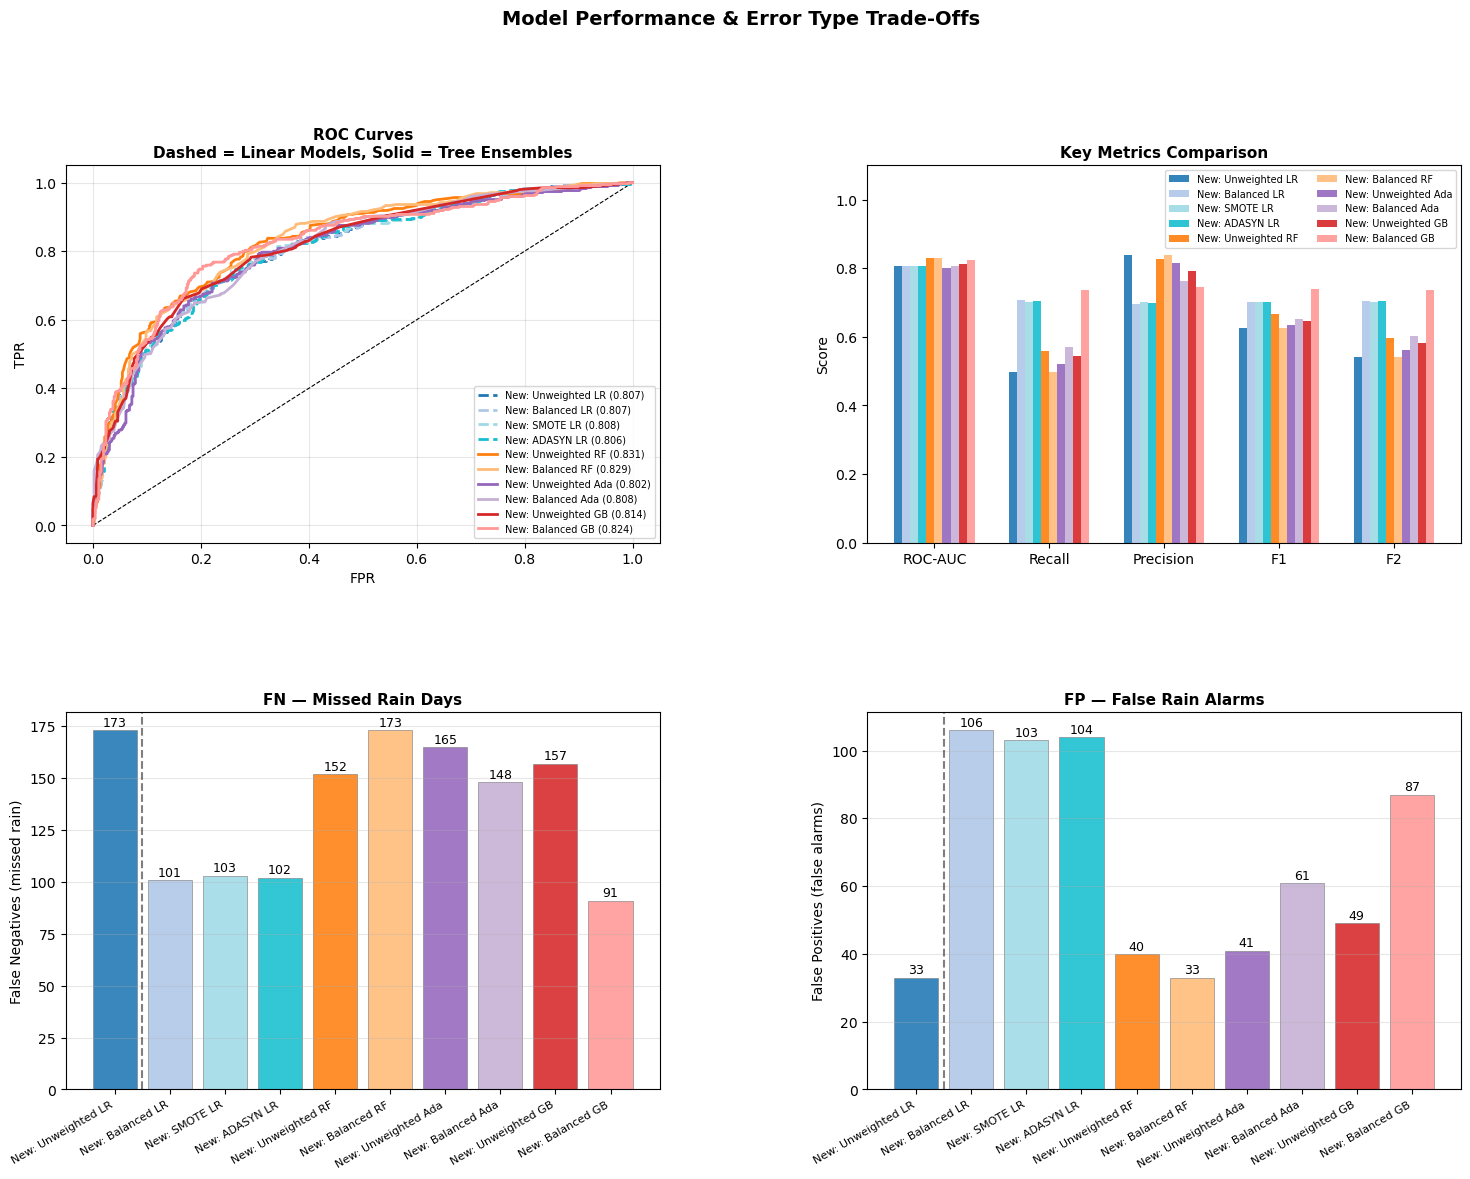


10-MODEL COMPREHENSIVE PERFORMANCE COMPARISON
              Model  ROC-AUC  Recall  Precision     F1     F2  FN  FP
 New: Unweighted LR   0.8069  0.4986     0.8390 0.6255 0.5426 173  33
   New: Balanced LR   0.8074  0.7072     0.6971 0.7022 0.7052 101 106
      New: SMOTE LR   0.8082  0.7014     0.7014 0.7014 0.7014 103 103
     New: ADASYN LR   0.8062  0.7043     0.7003 0.7023 0.7035 102 104
 New: Unweighted RF   0.8312  0.5594     0.8283 0.6678 0.5983 152  40
   New: Balanced RF   0.8289  0.4986     0.8390 0.6255 0.5426 173  33
New: Unweighted Ada   0.8025  0.5217     0.8145 0.6360 0.5621 165  41
  New: Balanced Ada   0.8081  0.5710     0.7636 0.6534 0.6013 148  61
 New: Unweighted GB   0.8140  0.5449     0.7932 0.6460 0.5813 157  49
   New: Balanced GB   0.8242  0.7362     0.7449 0.7405 0.7379  91  87


In [70]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    recall_score, precision_score, f1_score, fbeta_score
)

compare_models = [
    ("New: Unweighted LR",              y_test_nf, y_proba_nf,     y_pred_nf),
    ("New: Balanced LR",              y_test_nf, y_proba_nf_bal, y_pred_nf_bal),
    ("New: SMOTE LR",                  y_test_nf, y_proba_sm_nf,  y_pred_sm_nf),
    ("New: ADASYN LR",                y_test_nf, y_proba_ad_nf,  y_pred_ad_nf),
    ("New: Unweighted RF",            y_test_nf, y_proba_rfc_nf,  y_pred_rfc_nf),
    ("New: Balanced RF",              y_test_nf, y_proba_rfc_bal,  y_pred_rfc_bal),
    ("New: Unweighted Ada",           y_test_nf, y_proba_ada_nf,  y_pred_ada_nf),
    ("New: Balanced Ada",             y_test_nf, y_proba_ada_bal_nf,  y_pred_ada_bal_nf),
    ("New: Unweighted GB",            y_test_nf, y_proba_gb_nf,  y_pred_gb_nf),
    ("New: Balanced GB",              y_test_nf, y_proba_gb_bal_nf,  y_pred_gb_bal_nf)
]

# EXACTLY 10 custom colors mapped to your models
colors = [
    "#1f77b4", "#aec7e8", "#9edae5", "#17becf",  # Logistic Regression Family (Blues)
    "#ff7f0e", "#ffbb78",                        # Random Forest (Oranges)
    "#9467bd", "#c5b0d5",                        # AdaBoost (Purples)
    "#d62728", "#ff9896"                         # Gradient Boosting (Reds)
]

# Style distinction: Dashed for LR, Solid for Tree/Ensemble families
styles = ["--"]*4 + ["-"]*6

rows = []
for label, y_true, y_prob, y_p in compare_models:
    tn, fp, fn, tp = confusion_matrix(y_true, y_p).ravel()
    rows.append({
        "Model":     label,
        "ROC-AUC":   roc_auc_score(y_true, y_prob),
        "Recall":    recall_score(y_true, y_p, zero_division=0),
        "Precision": precision_score(y_true, y_p, zero_division=0),
        "F1":        f1_score(y_true, y_p, zero_division=0),
        "F2":        fbeta_score(y_true, y_p, beta=2, zero_division=0),
        "FN": fn, "FP": fp, "TP": tp, "TN": tn,
    })
res_df = pd.DataFrame(rows)
n = len(res_df)

# ── Layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# Panel 1: ROC curves
ax_roc = fig.add_subplot(gs[0, 0])
ax_roc.plot([0,1],[0,1],"k--",lw=0.8)
for (label, y_true, y_prob, _), c, ls in zip(compare_models, colors, styles):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax_roc.plot(fpr, tpr, color=c, lw=2, ls=ls, label=f"{label} ({auc:.3f})")
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.set_title("ROC Curves\nDashed = Linear Models, Solid = Tree Ensembles",
                 fontweight="bold", fontsize=11)
ax_roc.legend(fontsize=7, loc="lower right"); ax_roc.grid(alpha=0.3)

# Panel 2: Key metrics grouped bar
ax_bar = fig.add_subplot(gs[0, 1])
metric_cols = ["ROC-AUC", "Recall", "Precision", "F1", "F2"]
x = np.arange(len(metric_cols))
bar_w = 0.07  # Slighly adjusted width so 10 bars fit side-by-side
offsets = np.linspace(-(n-1)/2, (n-1)/2, n) * bar_w
for i, (row, c) in enumerate(zip(rows, colors)):
    vals = [row[m] for m in metric_cols]
    ax_bar.bar(x + offsets[i], vals, bar_w, label=row["Model"], color=c, alpha=0.9)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(metric_cols, fontsize=10)
ax_bar.set_ylim(0, 1.1); ax_bar.set_ylabel("Score")
ax_bar.set_title("Key Metrics Comparison", fontweight="bold", fontsize=11)
ax_bar.legend(fontsize=7, loc="upper right", ncol=2)

# Panel 3: FN comparison
ax_fn = fig.add_subplot(gs[1, 0])
ax_fn.bar(range(n), res_df["FN"], color=colors, alpha=0.88, edgecolor="grey", lw=0.5)
for i, v in enumerate(res_df["FN"]):
    ax_fn.text(i, v + (ax_fn.get_ylim()[1]*0.01), str(int(v)), ha="center", fontsize=9)
ax_fn.set_xticks(range(n))
ax_fn.set_xticklabels(res_df["Model"], rotation=30, ha="right", fontsize=8)
ax_fn.set_ylabel("False Negatives (missed rain)")
ax_fn.set_title("FN — Missed Rain Days", fontweight="bold", fontsize=11)
# Slices layout right after baseline Linear Regressions
ax_fn.axvline(0.5, color="black", lw=1.5, ls="--", alpha=0.5) 
ax_fn.grid(axis="y", alpha=0.3)

# Panel 4: FP comparison
ax_fp = fig.add_subplot(gs[1, 1])
ax_fp.bar(range(n), res_df["FP"], color=colors, alpha=0.88, edgecolor="grey", lw=0.5)
for i, v in enumerate(res_df["FP"]):
    ax_fp.text(i, v + (ax_fp.get_ylim()[1]*0.01), str(int(v)), ha="center", fontsize=9)
ax_fp.set_xticks(range(n))
ax_fp.set_xticklabels(res_df["Model"], rotation=30, ha="right", fontsize=8)
ax_fp.set_ylabel("False Positives (false alarms)")
ax_fp.set_title("FP — False Rain Alarms", fontweight="bold", fontsize=11)
ax_fp.axvline(0.5, color="black", lw=1.5, ls="--", alpha=0.5)
ax_fp.grid(axis="y", alpha=0.3)

plt.suptitle("Model Performance & Error Type Trade-Offs",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(f"{PLOTS_DIR}/dc1_30_new_features_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "="*85)
print("10-MODEL COMPREHENSIVE PERFORMANCE COMPARISON")
print("="*85)
print(res_df[["Model","ROC-AUC","Recall","Precision","F1","F2","FN","FP"]]
      .to_string(index=False, float_format="{:.4f}".format))